# Quark Meson model

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use(["science", "grid"])
import pandas as pd
from pathlib import Path
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import h5py
import plot

In [76]:
RESULTS_DIR = "../results/QM"

In [77]:
csv_path = Path(RESULTS_DIR) / "UV_params.csv"
print(csv_path.resolve())

uv_params = pd.read_csv(
    csv_path, 
    comment='#',
    skiprows=[3],
    skipinitialspace=True
)

uv_params

/home/kilian/Code/FRG/results/QM/UV_params.csv


,-0.1,1,0,0.231517,35.0825,0.1
0,-0.10,1,0.3125,0.245014,124.076000,8.673620e-19
1,-0.10,1,0.6250,0.310098,52.729300,0.000000e+00
2,-0.10,1,0.9375,0.297579,347.503000,0.000000e+00
3,-0.10,1,1.2500,0.362262,79.333000,0.000000e+00
4,-0.10,1,1.5625,0.338136,33.411800,0.000000e+00
...,...,...,...,...,...,...
619,0.75,1,6.2500,0.000000,0.000000,2.413620e-05
620,0.75,1,6.5625,0.000754,0.006117,-4.336810e-19
621,0.75,1,6.8750,0.000767,0.007300,0.000000e+00
622,0.75,1,7.1875,0.000755,0.008224,0.000000e+00


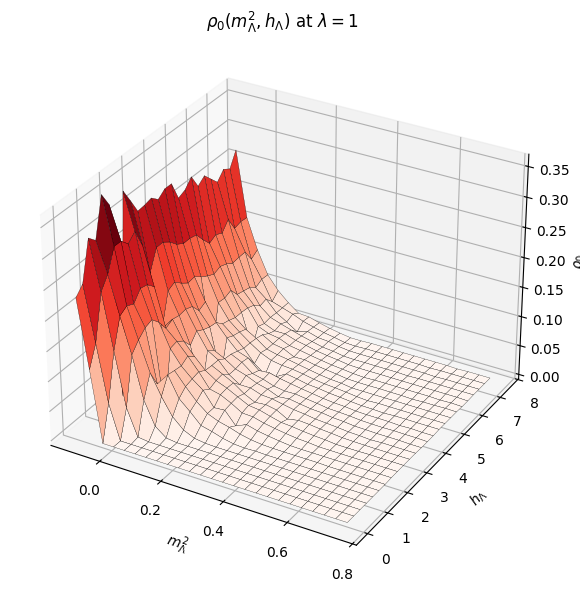

In [78]:
import numpy as np
import matplotlib.pyplot as plt

col_names = ["m2", "lambda", "h", "rho0", "m2_sigma", "m2_pi", "extra"]  # "extra" = phantom col from trailing comma

uv_params = pd.read_csv(
    csv_path,
    comment="#",
    header=None,          
    names=col_names,
    skipinitialspace=True,
)

uv_params = uv_params.drop(columns=["extra"])
uv_params

# Pick a fixed lambda slice (or set this explicitly, e.g. lambda_fixed = 1.0)
lambda_fixed = uv_params["lambda"].iloc[0]
df = uv_params[np.isclose(uv_params["lambda"], lambda_fixed)]

# Pivot into a grid: rows = m2, columns = h
pivot = df.pivot(index="m2", columns="h", values="rho0")

M2, H = np.meshgrid(pivot.index.values, pivot.columns.values, indexing="ij")
RHO0 = pivot.values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(M2, H, RHO0, cmap="Reds", edgecolor="k", linewidth=0.2)

ax.set_xlabel(r"$m^2_\Lambda$")
ax.set_ylabel(r"$h_\Lambda$")
ax.set_zlabel(r"$\rho_0$")
ax.set_title(rf"$\rho_0(m^2_\Lambda, h_\Lambda)$ at $\lambda = {lambda_fixed:.3g}$")

plt.tight_layout()
plt.show()